In [38]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# Load a specific output folder (recommended) OR auto-pick newest
from pathlib import Path
import time
import sys
import importlib.util

# Option A (recommended): point directly to a specific run folder
OUTPUT_DIR = Path(r"C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04")

# Option B: auto-pick newest
# _out_root = Path(r"C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\3D spherical robot\outputs")
# OUTPUT_DIR = max(_out_root.iterdir(), key=lambda p: p.stat().st_mtime)

# Basic guardrails
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {OUTPUT_DIR}")

q_path = OUTPUT_DIR / "q_save.npy"
u_path = OUTPUT_DIR / "u_save.npy"
X_path = OUTPUT_DIR / "X_save.npy"
for p in [q_path, u_path, X_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using output:", OUTPUT_DIR)
print("q_save.npy mtime:", time.ctime(q_path.stat().st_mtime))

q = np.load(q_path)   # (8, ntime): x, y, z, psi, theta, phi, alpha_p, beta_p
u = np.load(u_path)   # (8, ntime): velocities
X = np.load(X_path)   # (nX, ntime): full state

params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}

# Contact data (nN=2: tread + riser, nF=4: 2 friction dirs per contact)
lambdaN = np.load(OUTPUT_DIR / "lambdaN_save.npy")  # (nN, ntime)
lambdaF = np.load(OUTPUT_DIR / "lambdaF_save.npy")  # (nF, ntime)
gNdot   = np.load(OUTPUT_DIR / "gNdot_save.npy")    # (nN, ntime)
gNddot  = np.load(OUTPUT_DIR / "gNddot_save.npy")   # (nN, ntime)
gammaF  = np.load(OUTPUT_DIR / "gammaF_save.npy")    # (nF, ntime)
contacts = np.load(OUTPUT_DIR / "contacts_save.npy") # (5*nN, ntime)
dtime_save = np.load(OUTPUT_DIR / "dtime_save.npy")  # (ntime,)

nN = lambdaN.shape[0]
nF = lambdaF.shape[0]

# Physical params
R = float(params.get("R", 0.1))
l_pendulum = float(params.get("l_pendulum", 0.05))
m_sphere = float(params.get("m_sphere", 1.0))
m_pendulum_val = float(params.get("m_pendulum", 0.1))
dtime = float(params.get("dtime", 2e-3))
ntime = q.shape[1]

# Import Simulation from the output folder's copy (exact code that produced the data)
_sim_py = OUTPUT_DIR / "Spherical_robot_3D.py"
spec = importlib.util.spec_from_file_location("Spherical_robot_3D_saved", str(_sim_py))
_sim_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(_sim_mod)

# Build stair profile using the saved Simulation class
# Create a lightweight stub with just the stair params to call _build_stair_profile
_stub = object.__new__(_sim_mod.Simulation)
_stub.n_stairs     = int(params.get("n_stairs", 0))
_stub.stair_width  = float(params.get("stair_width", 0.3))
_stub.stair_height = float(params.get("stair_height", 0.05))
_stub.stair_x_start = float(params.get("stair_x_start", 0.5))
_stub.fillet_radius = float(params.get("fillet_radius", 0))
_stub.R             = R
_stub._build_stair_profile()
_stub._classify_segments()

n_stairs     = _stub.n_stairs
stair_width  = _stub.stair_width
stair_height = _stub.stair_height
stair_x_start = _stub.stair_x_start
fillet_radius = _stub.fillet_radius
stair_segs   = _stub.stair_segments

# Compute normal gaps gN (tread & riser) at every timestep
gN = np.zeros((nN, ntime))
for i in range(ntime):
    gN[0, i] = _stub._compute_tread_gap(q[0, i], q[2, i])[0]
    if nN > 1:
        gN[1, i] = _stub._compute_riser_gap(q[0, i], q[2, i])[0]

# Reconstruct time array from dtime_save
t = np.zeros(ntime)
for i in range(1, ntime):
    t[i] = t[i-1] + dtime_save[i] if i < len(dtime_save) else t[i-1] + dtime

# DOF labels
dof_labels = ['x', 'y', 'z', r'$\psi$', r'$\theta$', r'$\phi$', r'$\alpha_p$', r'$\beta_p$']
vel_labels = [r'$\dot{x}$', r'$\dot{y}$', r'$\dot{z}$', r'$\dot{\psi}$', r'$\dot{\theta}$', r'$\dot{\phi}$', r'$\dot{\alpha}_p$', r'$\dot{\beta}_p$']

print(f"q shape: {q.shape}  (8 DOF x {ntime} steps)")
print(f"R={R}, l_pendulum={l_pendulum}, m_sphere={m_sphere}, m_pendulum={m_pendulum_val}")
print(f"dtime={dtime}, total time={t[-1]:.4f}")
print(f"nN={nN}, nF={nF}, n_stairs={n_stairs}")
print(f"stair_segs: {len(stair_segs)} segments")
print(f"q[:,0] = {q[:, 0]}")
print(f"u[:,0] = {u[:, 0]}")

Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04
q_save.npy mtime: Wed Apr 15 10:20:36 2026
q shape: (8, 1000)  (8 DOF x 1000 steps)
R=0.18, l_pendulum=0.15, m_sphere=1.0, m_pendulum=0.5
dtime=0.00626418390534633, total time=6.2579
nN=2, nF=4, n_stairs=2
stair_segs: 5 segments
q[:,0] = [-0.5        0.         0.18       0.         0.         0.
  2.0943951  0.       ]
u[:,0] = [ 0.  0.  0.  0.  0.  0. -7.  0.]


## Generalized Coordinates
Plot all 8 DOFs: `x, y, z, ψ, θ, φ, α_p, β_p`

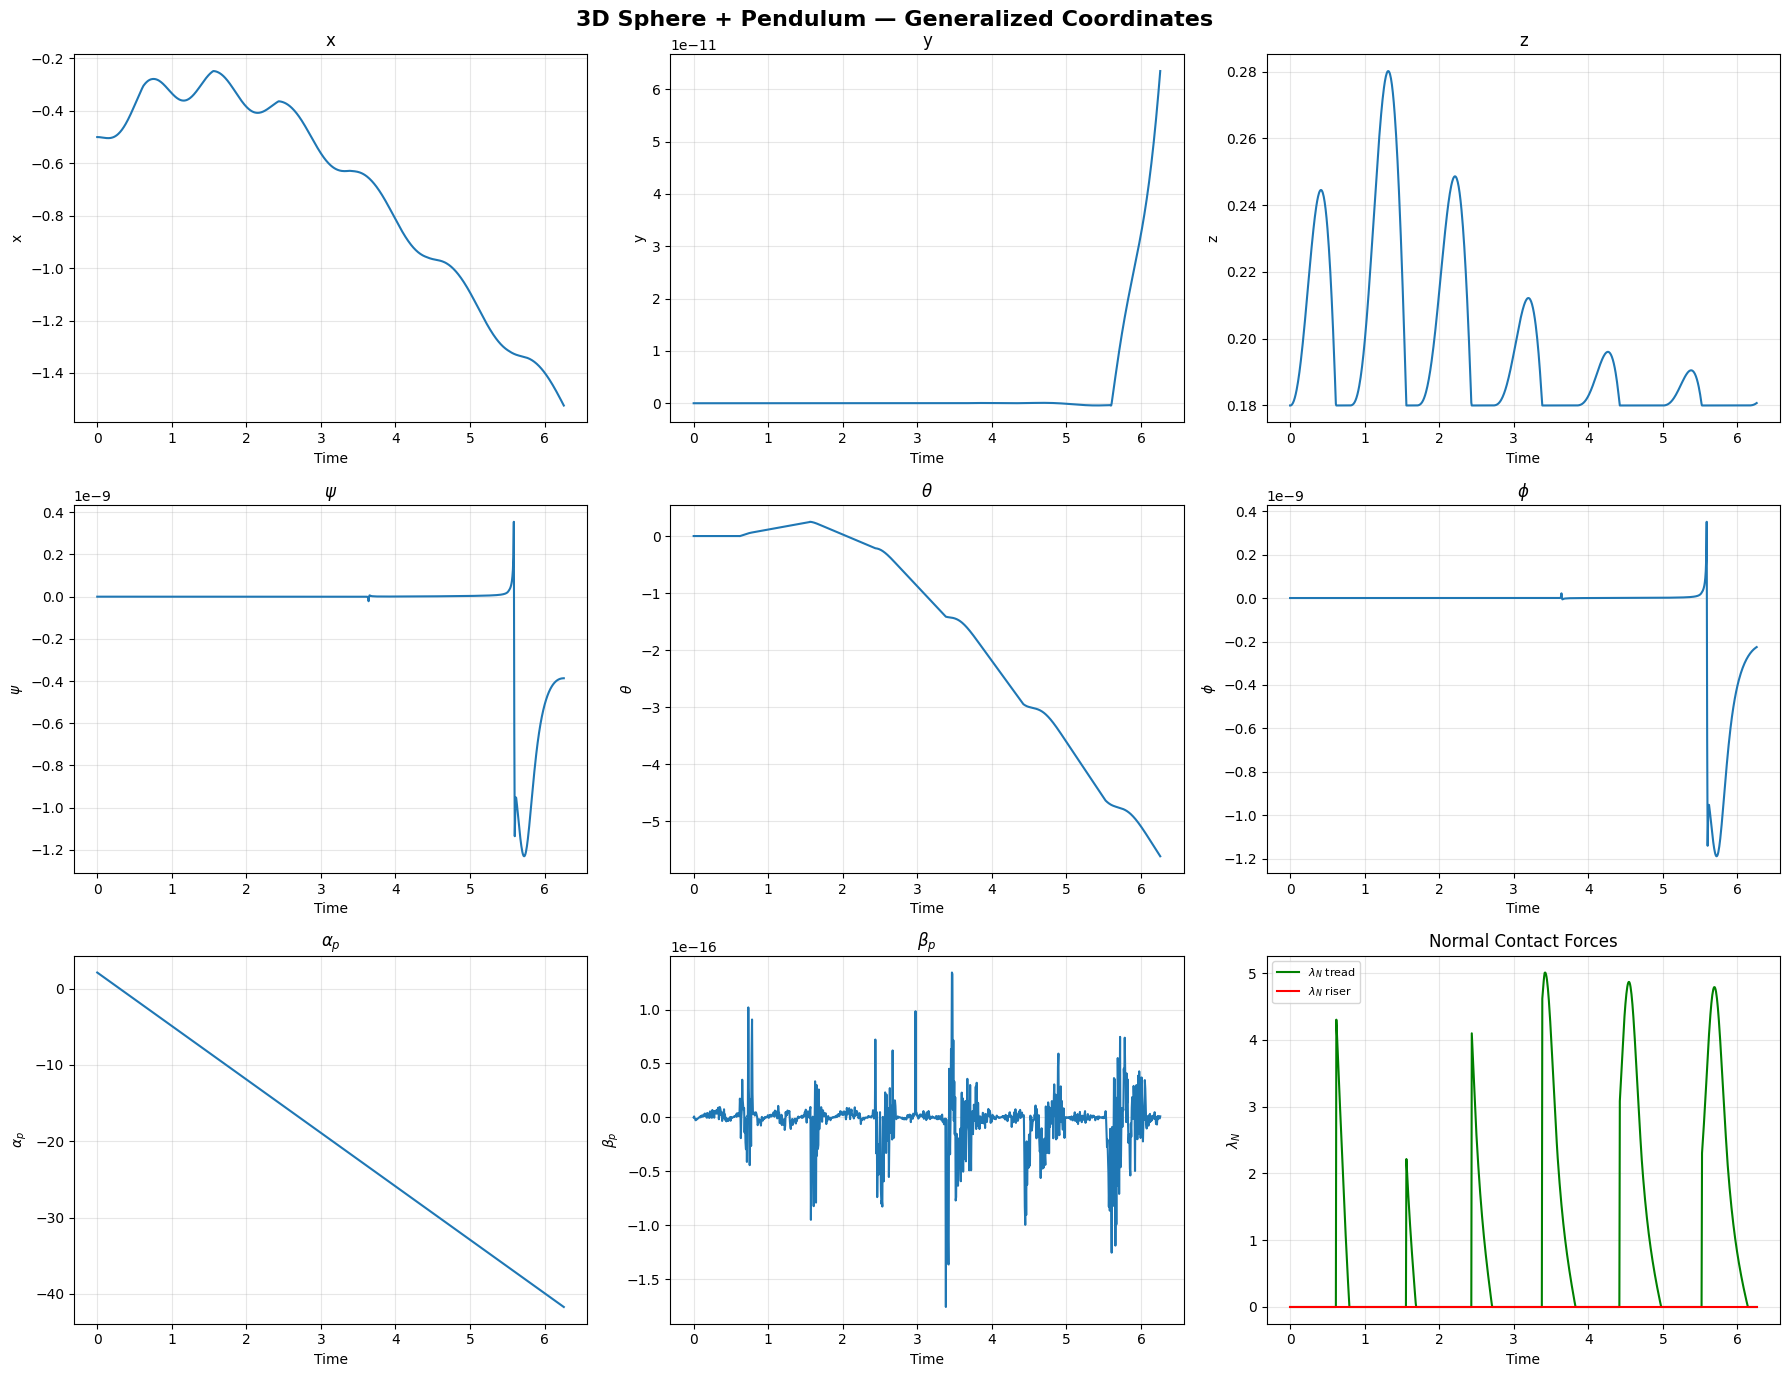

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('3D Sphere + Pendulum — Generalized Coordinates', fontsize=16, fontweight='bold')

for i in range(8):
    ax = axes[i // 3, i % 3]
    ax.plot(t, q[i, :], linewidth=1.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(dof_labels[i])
    ax.set_title(dof_labels[i])
    ax.grid(True, alpha=0.3)

# Last subplot: normal contact forces (tread + riser)
ax = axes[2, 2]
ax.plot(t, lambdaN[0, :], 'g-', linewidth=1.5, label=r'$\lambda_{N}$ tread')
if nN > 1:
    ax.plot(t, lambdaN[1, :], 'r-', linewidth=1.5, label=r'$\lambda_{N}$ riser')
ax.set_xlabel('Time')
ax.set_ylabel(r'$\lambda_N$')
ax.set_title('Normal Contact Forces')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Generalized Velocities

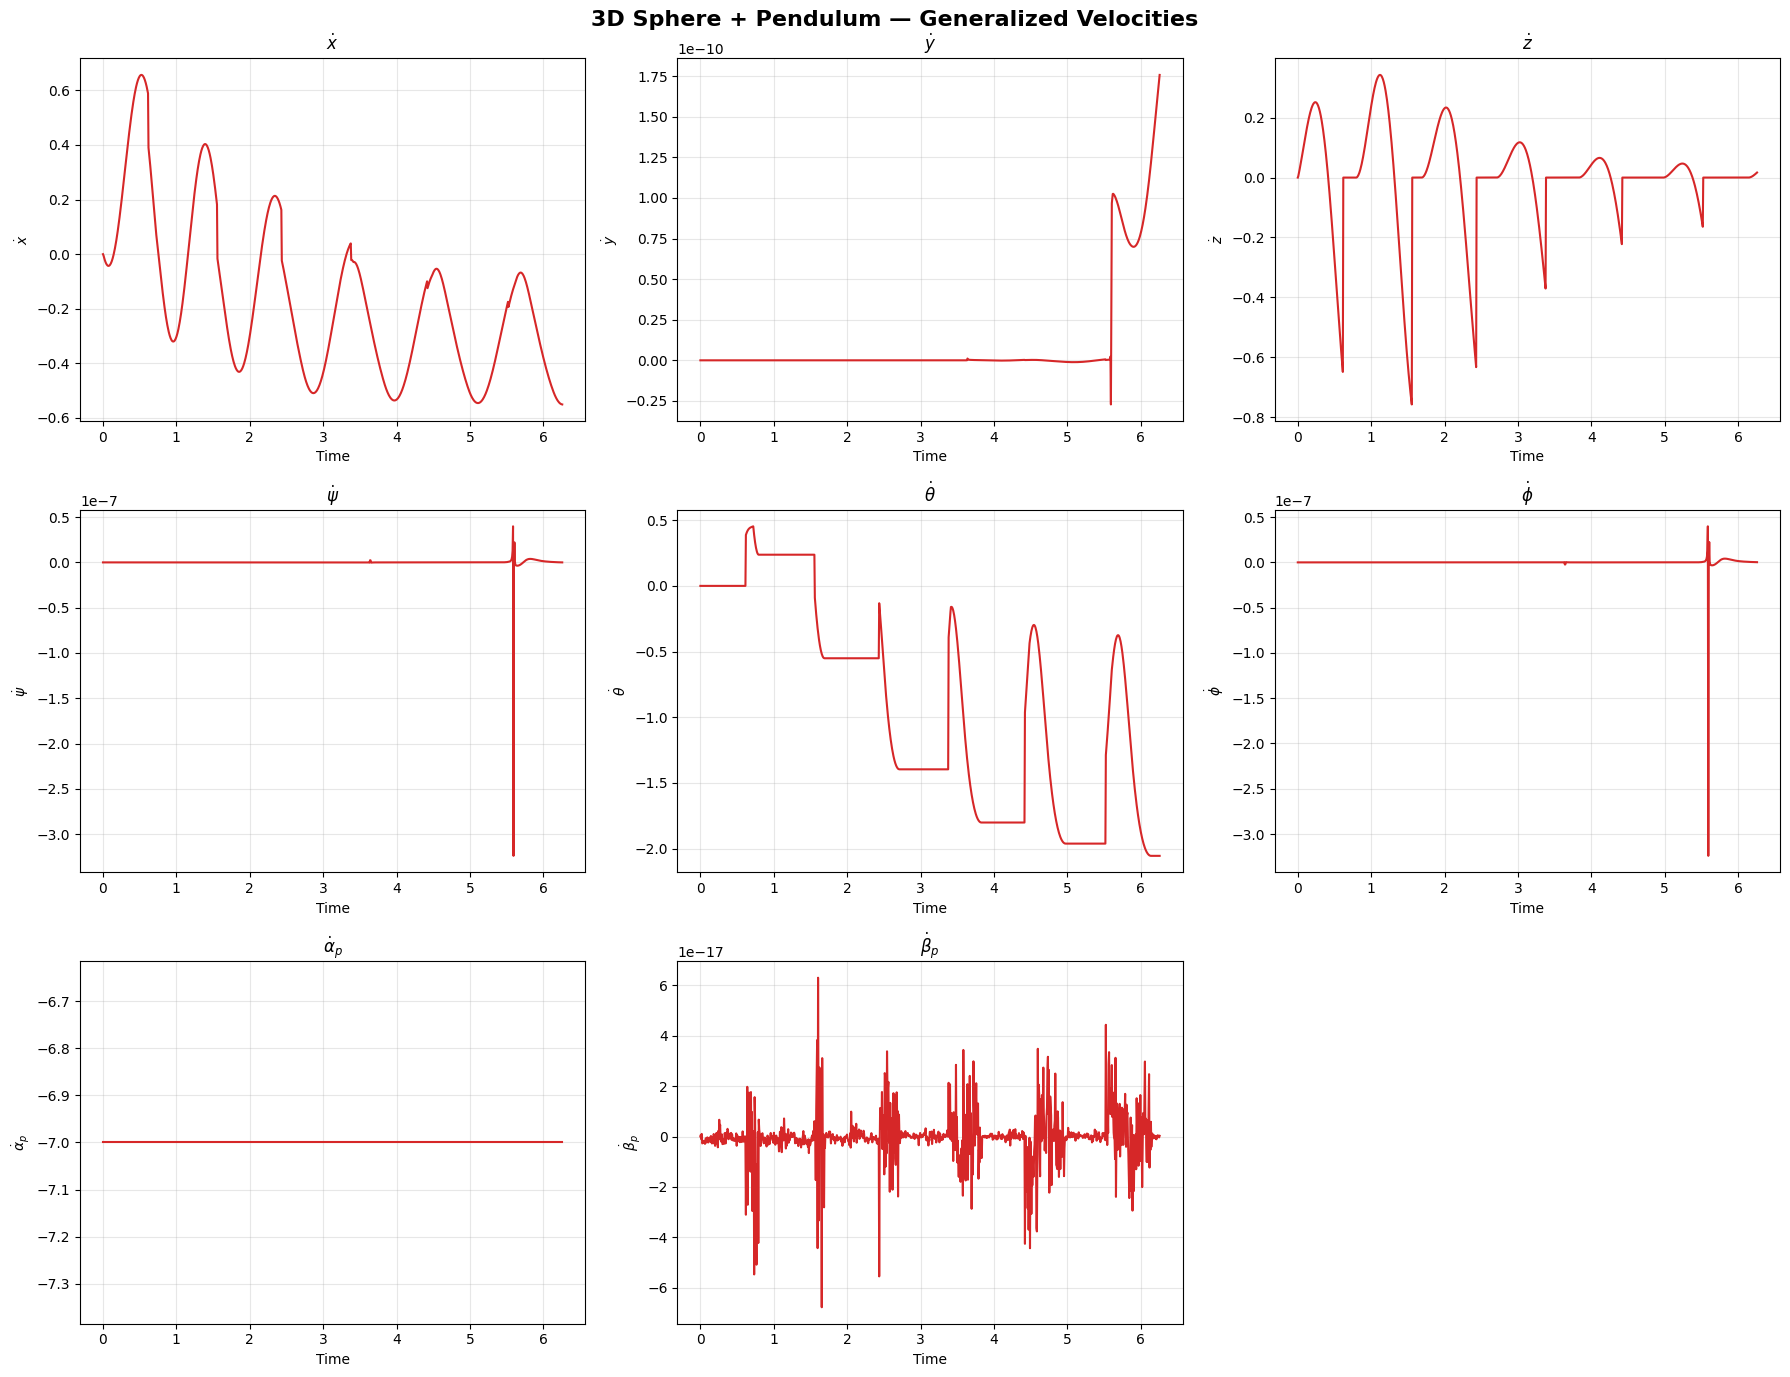

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('3D Sphere + Pendulum — Generalized Velocities', fontsize=16, fontweight='bold')

for i in range(8):
    ax = axes[i // 3, i % 3]
    ax.plot(t, u[i, :], linewidth=1.5, color='tab:red')
    ax.set_xlabel('Time')
    ax.set_ylabel(vel_labels[i])
    ax.set_title(vel_labels[i])
    ax.grid(True, alpha=0.3)

axes[2, 2].axis('off')
plt.tight_layout()
plt.show()

## Contact Forces & Gap Quantities

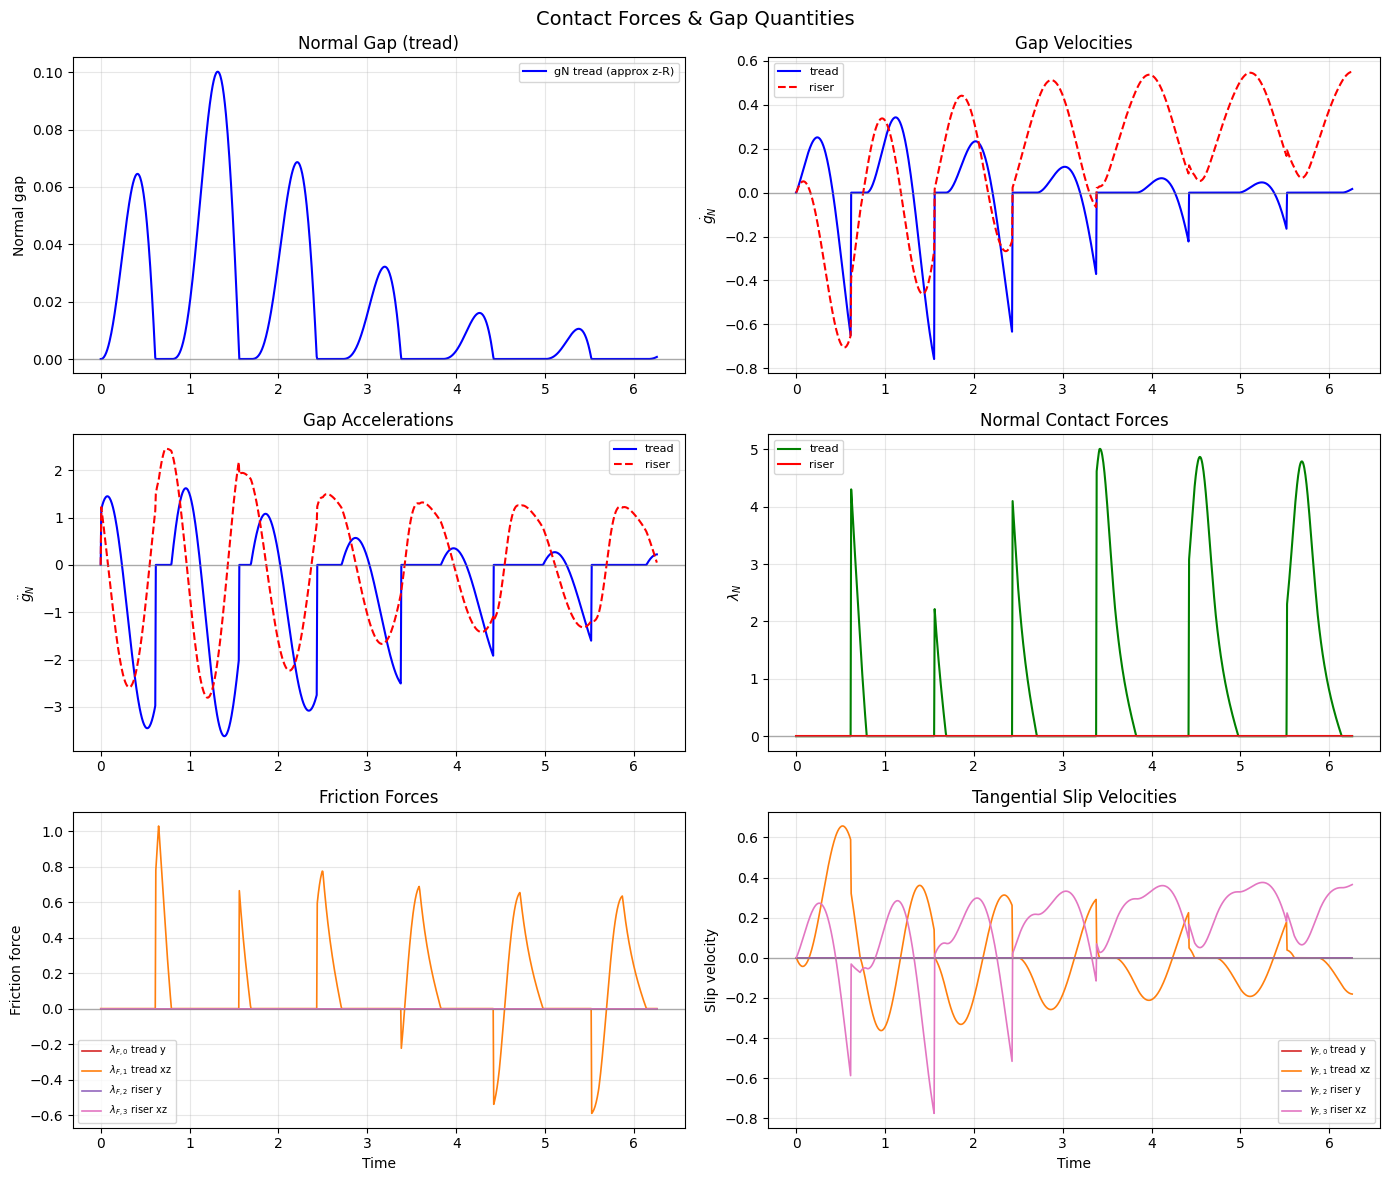

In [42]:
fig_contact, axes_c = plt.subplots(3, 2, figsize=(14, 12))
fig_contact.suptitle('Contact Forces & Gap Quantities', fontsize=14)

# 1) Normal gaps (tread & riser)
ax = axes_c[0, 0]
ax.plot(t, gNdot[0, :] * 0 + (q[2, :] - R), 'b-', lw=1.5, label='gN tread (approx z-R)')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel('Normal gap')
ax.set_title('Normal Gap (tread)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# 2) Normal gap velocities
ax = axes_c[0, 1]
ax.plot(t, gNdot[0, :], 'b-', lw=1.5, label='tread')
if nN > 1:
    ax.plot(t, gNdot[1, :], 'r--', lw=1.5, label='riser')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel(r'$\dot{g}_N$')
ax.set_title('Gap Velocities')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Normal gap accelerations
ax = axes_c[1, 0]
ax.plot(t, gNddot[0, :], 'b-', lw=1.5, label='tread')
if nN > 1:
    ax.plot(t, gNddot[1, :], 'r--', lw=1.5, label='riser')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel(r'$\ddot{g}_N$')
ax.set_title('Gap Accelerations')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4) Normal forces
ax = axes_c[1, 1]
ax.plot(t, lambdaN[0, :], 'g-', lw=1.5, label='tread')
if nN > 1:
    ax.plot(t, lambdaN[1, :], 'r-', lw=1.5, label='riser')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_ylabel(r'$\lambda_N$')
ax.set_title('Normal Contact Forces')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5) Friction forces (4 components: tread y-lat, tread xz-tang, riser y-lat, riser xz-tang)
ax = axes_c[2, 0]
fric_labels = [r'$\lambda_{F,0}$ tread y', r'$\lambda_{F,1}$ tread xz',
               r'$\lambda_{F,2}$ riser y', r'$\lambda_{F,3}$ riser xz']
colors = ['tab:red', 'tab:orange', 'tab:purple', 'tab:pink']
for j in range(nF):
    ax.plot(t, lambdaF[j, :], colors[j % len(colors)], lw=1.2, label=fric_labels[j] if j < len(fric_labels) else f'F{j}')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('Time')
ax.set_ylabel('Friction force')
ax.set_title('Friction Forces')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

# 6) Tangential slip velocities
ax = axes_c[2, 1]
slip_labels = [r'$\gamma_{F,0}$ tread y', r'$\gamma_{F,1}$ tread xz',
               r'$\gamma_{F,2}$ riser y', r'$\gamma_{F,3}$ riser xz']
for j in range(nF):
    ax.plot(t, gammaF[j, :], colors[j % len(colors)], lw=1.2, label=slip_labels[j] if j < len(slip_labels) else f'γF{j}')
ax.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax.set_xlabel('Time')
ax.set_ylabel('Slip velocity')
ax.set_title('Tangential Slip Velocities')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Contact Index Sets (A, B, C, D, E)

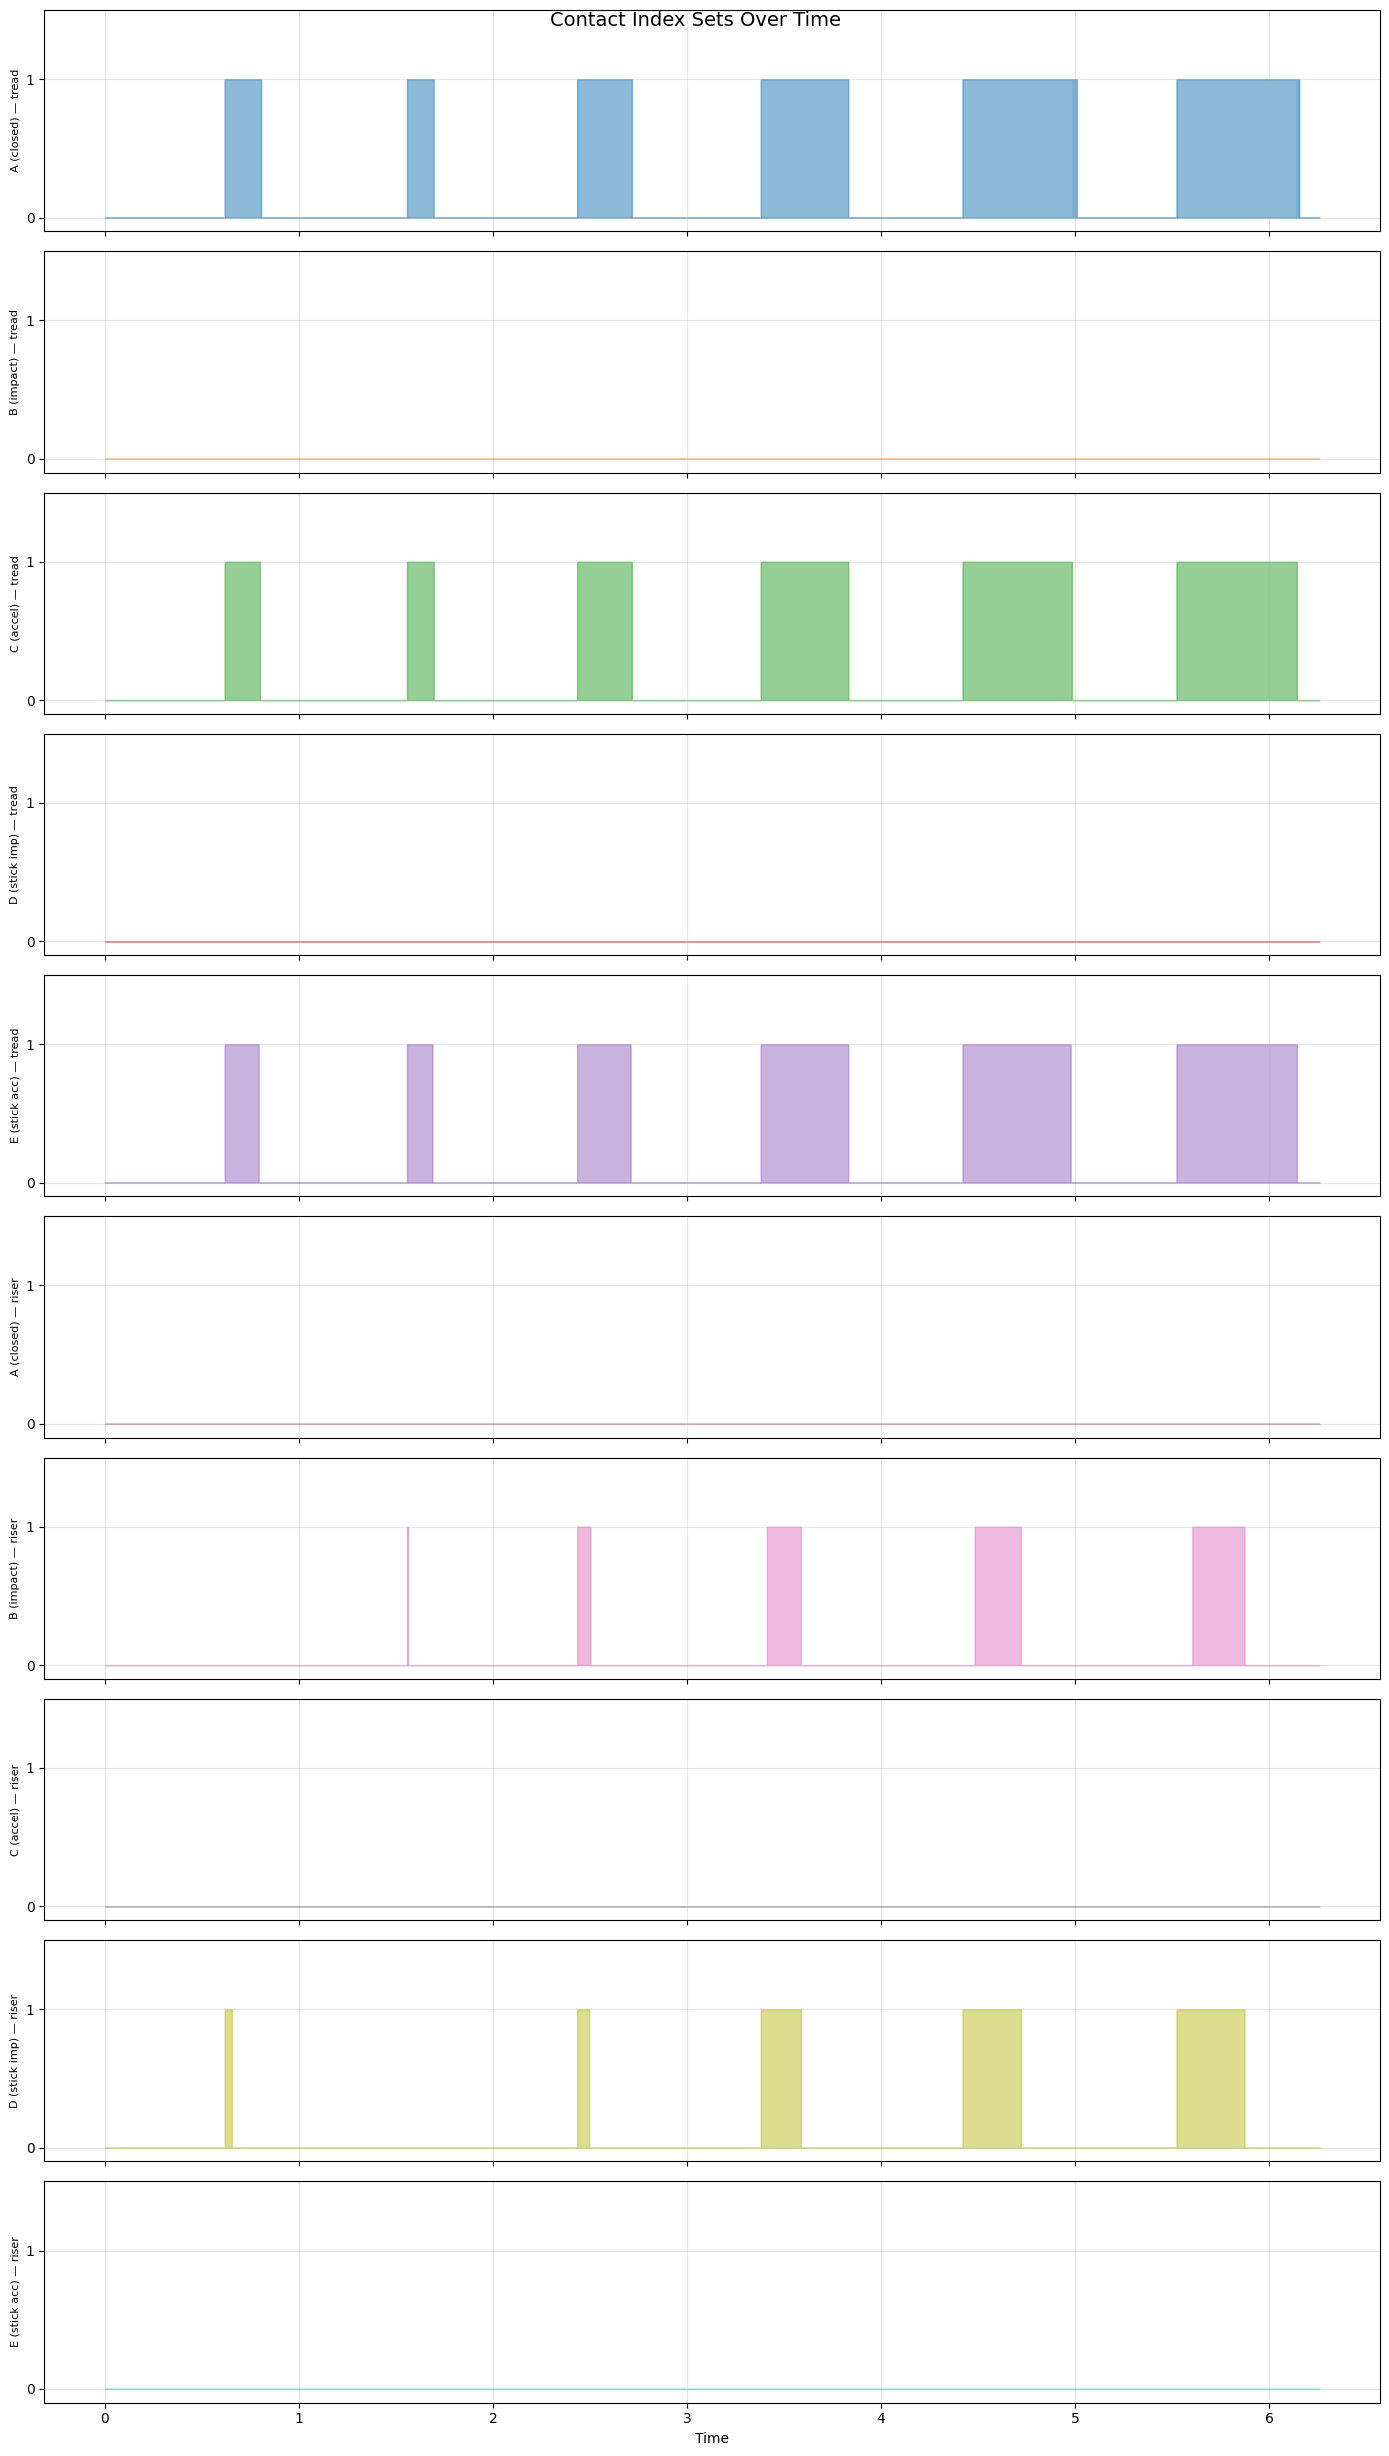

In [43]:
# contacts_save has shape (5*nN, ntime)
# For nN=2: rows 0-4 are contact 0 (tread), rows 5-9 are contact 1 (riser)
# Order per contact: A (closed), B (impact), C (accel), D (stick imp), E (stick vel)
set_labels_base = ['A (closed)', 'B (impact)', 'C (accel)', 'D (stick imp)', 'E (stick acc)']
contact_names = ['tread', 'riser']

n_rows = 5 * nN
fig_idx, axes_idx = plt.subplots(n_rows, 1, figsize=(14, 2.5 * nN * 5), sharex=True)
fig_idx.suptitle('Contact Index Sets Over Time', fontsize=14)

if n_rows == 1:
    axes_idx = [axes_idx]

for k in range(nN):
    for j in range(5):
        row = k * 5 + j
        label = f'{set_labels_base[j]} — {contact_names[k] if k < len(contact_names) else f"contact {k}"}'
        color = f'C{j}' if k == 0 else f'C{j+5}'
        axes_idx[row].fill_between(t, contacts[row, :], step='mid', alpha=0.5, color=color)
        axes_idx[row].set_ylabel(label, fontsize=8)
        axes_idx[row].set_ylim(-0.1, 1.5)
        axes_idx[row].set_yticks([0, 1])
        axes_idx[row].grid(True, alpha=0.3)

axes_idx[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

## Sphere Trajectory (x-z plane) and Pendulum

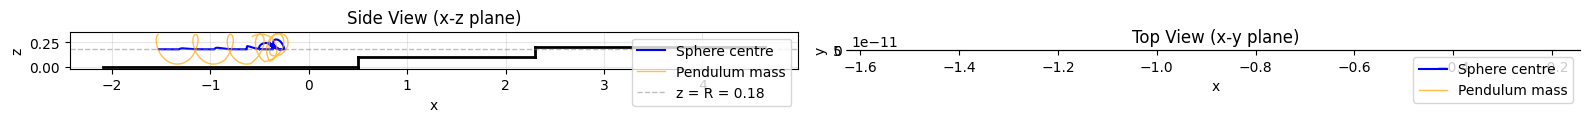

In [44]:
# Compute pendulum mass position in incline frame
def rotation_matrix(psi, theta, phi):
    c_psi, s_psi = np.cos(psi), np.sin(psi)
    c_th, s_th = np.cos(theta), np.sin(theta)
    c_phi, s_phi = np.cos(phi), np.sin(phi)
    return np.array([
        [c_psi*c_th, c_psi*s_th*s_phi - s_psi*c_phi, c_psi*s_th*c_phi + s_psi*s_phi],
        [s_psi*c_th, s_psi*s_th*s_phi + c_psi*c_phi, s_psi*s_th*c_phi - c_psi*s_phi],
        [-s_th,      c_th*s_phi,                      c_th*c_phi]
    ])

xG, yG, zG = q[0, :], q[1, :], q[2, :]
psi, theta, phi_euler = q[3, :], q[4, :], q[5, :]
alpha_p, beta_p = q[6, :], q[7, :]

# Pendulum tip positions
xP = np.zeros(ntime)
yP = np.zeros(ntime)
zP = np.zeros(ntime)

for i in range(ntime):
    R_mat = rotation_matrix(psi[i], theta[i], phi_euler[i])
    ca, sa = np.cos(alpha_p[i]), np.sin(alpha_p[i])
    cb, sb = np.cos(beta_p[i]), np.sin(beta_p[i])
    e_body = np.array([ca*cb, ca*sb, sa])
    tip = R_mat @ (l_pendulum * e_body)
    xP[i] = xG[i] + tip[0]
    yP[i] = yG[i] + tip[1]
    zP[i] = zG[i] + tip[2]

def draw_stairs_xz(ax, stair_segs, x_lo, x_hi, color='k', lw=2):
    """Draw stair profile line segments on an x-z axes, clipped to [x_lo, x_hi]."""
    for seg in stair_segs:
        x1, z1, x2, z2 = seg
        # Clip horizontal segments to visible range
        if abs(z2 - z1) < 1e-12:  # horizontal
            x1 = max(x1, x_lo)
            x2 = min(x2, x_hi)
            if x1 >= x2:
                continue
        else:  # vertical
            if x1 < x_lo or x1 > x_hi:
                continue
        ax.plot([x1, x2], [z1, z2], color=color, lw=lw)

# Plot x-z side view
fig_traj, (ax_xz, ax_xy) = plt.subplots(1, 2, figsize=(16, 6))

# x-z view (side)
ax_xz.plot(xG, zG, 'b-', lw=1.5, label='Sphere centre')
ax_xz.plot(xP, zP, 'orange', lw=1, alpha=0.7, label='Pendulum mass')

# Compute view limits — include stair region if stairs exist
pad = 3 * R
x_lo = float(min(np.min(xG), np.min(xP))) - pad
x_hi = float(max(np.max(xG), np.max(xP))) + pad
if n_stairs > 0:
    stair_x_end = stair_x_start + n_stairs * stair_width
    x_hi = max(x_hi, stair_x_end + pad)
    z_hi = n_stairs * stair_height + 2 * R + pad
else:
    z_hi = float(max(np.max(zG), np.max(zP))) + pad

if n_stairs > 0:
    draw_stairs_xz(ax_xz, stair_segs, x_lo, x_hi, color='k', lw=2)
else:
    ax_xz.axhline(0.0, color='k', lw=2, label='Ground')

ax_xz.axhline(R, color='gray', lw=1, ls='--', alpha=0.5, label=f'z = R = {R}')
ax_xz.set_xlabel('x')
ax_xz.set_ylabel('z')
ax_xz.set_title('Side View (x-z plane)')
ax_xz.set_aspect('equal')
ax_xz.grid(True, alpha=0.3)
ax_xz.legend()

# x-y view (top-down)
ax_xy.plot(xG, yG, 'b-', lw=1.5, label='Sphere centre')
ax_xy.plot(xP, yP, 'orange', lw=1, alpha=0.7, label='Pendulum mass')
ax_xy.set_xlabel('x')
ax_xy.set_ylabel('y')
ax_xy.set_title('Top View (x-y plane)')
ax_xy.set_aspect('equal')
ax_xy.grid(True, alpha=0.3)
ax_xy.legend()

plt.tight_layout()
plt.show()

## 3D Rendered Animation (PyVista)
GPU-accelerated rendering with smooth shading, lighting, and materials. Saved as GIF and MP4.

Rendering 334 frames (of 1000)
  frame 1/334  t=0.000s
  frame 51/334  t=0.940s
  frame 101/334  t=1.879s
  frame 151/334  t=2.819s
  frame 201/334  t=3.759s
  frame 251/334  t=4.698s
  frame 301/334  t=5.638s


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


GIF saved: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_render_sphere3d_2026-04-15_10-17-04.gif
MP4 saved: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_render_sphere3d_2026-04-15_10-17-04.mp4


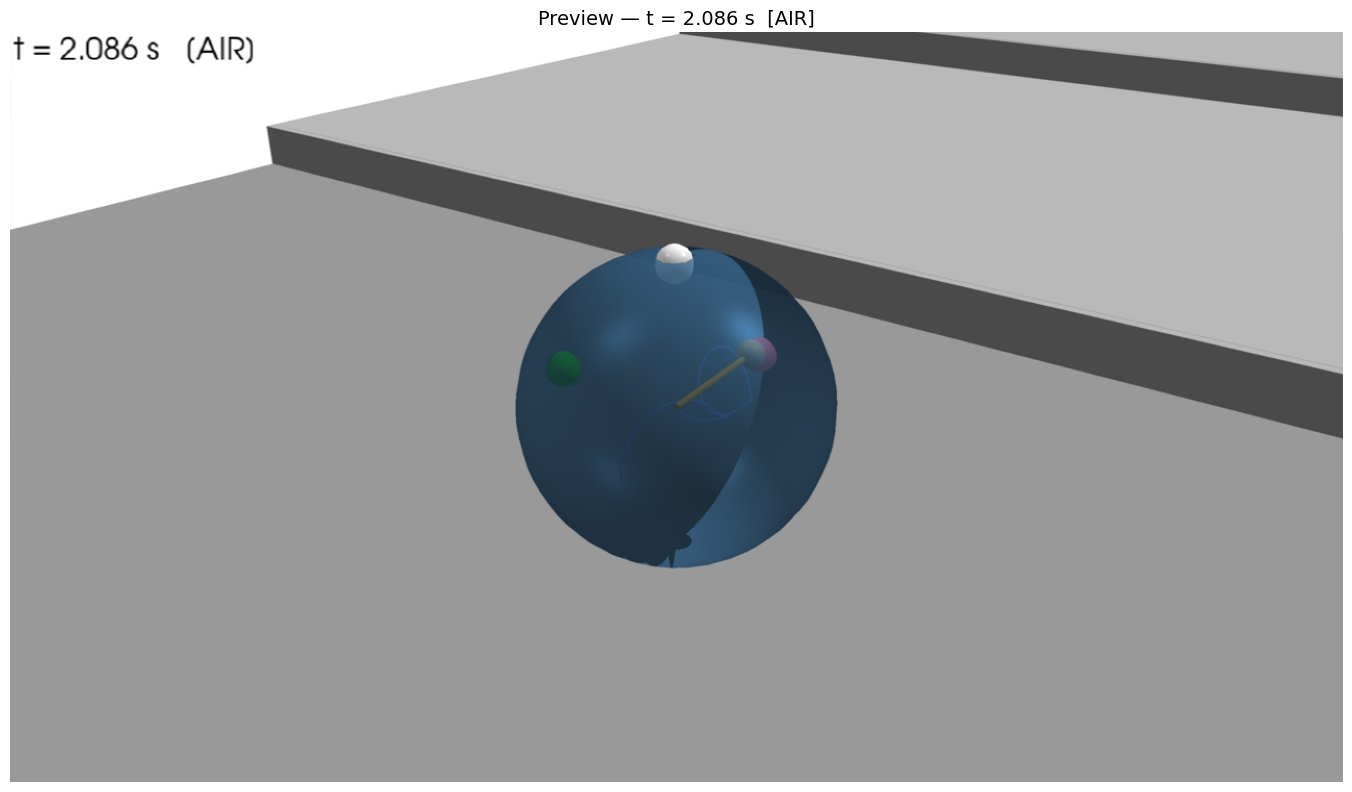

Done.


In [45]:
import pyvista as pv

pv.global_theme.background = 'white'
pv.global_theme.anti_aliasing = 'ssaa'

# ── Subsample frames ─────────────────────────────────────────
n_render = 300
skip_r = max(1, ntime // n_render)
render_idx = list(range(0, ntime, skip_r))
print(f"Rendering {len(render_idx)} frames (of {ntime})")

# ── Bounds ────────────────────────────────────────────────────
y_ext = 2.0
x_lo_r = float(np.min(xG)) - 0.5
x_hi_r = float(np.max(xG)) + 0.5
z_hi_r = float(max(np.max(zG), np.max(zP))) + 4 * R
if n_stairs > 0:
    x_hi_r = max(x_hi_r, stair_x_start + n_stairs * stair_width + 0.3)
    z_hi_r = max(z_hi_r, n_stairs * stair_height + 2 * R + 0.5)

# ── Build ground / stairs as solid 3D boxes ──────────────────
ground_meshes = []
ground_thickness = 0.02

if n_stairs > 0:
    ground_meshes.append(pv.Box(bounds=(
        x_lo_r, stair_x_start, -y_ext, y_ext, -ground_thickness, 0.0)))
    for si in range(n_stairs):
        xl = stair_x_start + si * stair_width
        xr = xl + stair_width if si < n_stairs - 1 else x_hi_r
        hc = (si + 1) * stair_height
        hp = si * stair_height
        ground_meshes.append(pv.Box(bounds=(
            xl, xr, -y_ext, y_ext, hc - ground_thickness, hc)))
        ground_meshes.append(pv.Box(bounds=(
            xl - ground_thickness, xl, -y_ext, y_ext, hp, hc)))
else:
    ground_meshes.append(pv.Box(bounds=(
        x_lo_r, x_hi_r, -y_ext, y_ext, -ground_thickness, 0.0)))

# ── Contact point helper ─────────────────────────────────────
def _contact_points(idx):
    cx, cz, cy = xG[idx], zG[idx], yG[idx]
    A_tread = contacts[0, idx] if contacts.shape[0] > 0 else 0
    A_riser = contacts[5, idx] if contacts.shape[0] > 5 else 0
    lN_t = lambdaN[0, idx]
    lN_r = lambdaN[1, idx] if nN > 1 else 0.0
    z_surf = 0.0
    riser_x = None
    if n_stairs > 0:
        for si in range(n_stairs):
            sx = stair_x_start + si * stair_width
            if cx >= sx:
                z_surf = (si + 1) * stair_height
                riser_x = sx
    tread_pt = np.array([cx, cy, z_surf])
    riser_pt = np.array([riser_x if riser_x else cx, cy, cz]) if riser_x else np.array([cx, cy, cz])
    return tread_pt, riser_pt, bool(A_tread), bool(A_riser), lN_t, lN_r

# ── Rotation marker helper ───────────────────────────────────
# 3 dots on the sphere surface along body axes to show rotation
_marker_body = R * 0.95 * np.array([
    [1, 0, 0],   # body +x  (red)
    [0, 1, 0],   # body +y  (green)
    [0, 0, 1],   # body +z  (white)
])
_mk_colors = ['red', '#00cc00', 'white']
_mk_r = R * 0.12

def _marker_positions(idx):
    Rot = rotation_matrix(psi[idx], theta[idx], phi_euler[idx])
    centre = np.array([xG[idx], yG[idx], zG[idx]])
    return [centre + Rot @ m for m in _marker_body]

# ── Plotter setup ────────────────────────────────────────────
plotter = pv.Plotter(off_screen=True, window_size=[1920, 1080])

for gm in ground_meshes:
    plotter.add_mesh(gm, color='#d0d0d0', ambient=0.25, diffuse=0.65,
                     specular=0.15, smooth_shading=False,
                     show_edges=True, edge_color='#999999', line_width=1)

# Sphere
sphere_actor = plotter.add_mesh(
    pv.Sphere(radius=R, center=(xG[0], yG[0], zG[0]),
              theta_resolution=32, phi_resolution=32),
    color='steelblue', opacity=0.75, ambient=0.2, diffuse=0.6,
    specular=0.5, specular_power=30, smooth_shading=True)

# Rotation markers
_mk_pos0 = _marker_positions(0)
mk_actors = []
for _mi in range(3):
    mk_actors.append(plotter.add_mesh(
        pv.Sphere(radius=_mk_r, center=_mk_pos0[_mi],
                  theta_resolution=10, phi_resolution=10),
        color=_mk_colors[_mi], ambient=0.4, diffuse=0.6,
        specular=0.3, smooth_shading=True))

# Pendulum rod
rod_actor = plotter.add_mesh(
    pv.Line((xG[0], yG[0], zG[0]), (xP[0], yP[0], zP[0])).tube(radius=0.004),
    color='orange', ambient=0.3, diffuse=0.6, specular=0.4,
    specular_power=20, smooth_shading=True)

# Pendulum mass
pend_actor = plotter.add_mesh(
    pv.Sphere(radius=R * 0.1, center=(xP[0], yP[0], zP[0]),
              theta_resolution=16, phi_resolution=16),
    color='darkorange', ambient=0.2, diffuse=0.6, specular=0.5,
    specular_power=30, smooth_shading=True)

# Centre marker
ctr_actor = plotter.add_mesh(
    pv.Sphere(radius=R * 0.08, center=(xG[0], yG[0], zG[0]),
              theta_resolution=12, phi_resolution=12),
    color='navy', ambient=0.3, diffuse=0.7, smooth_shading=True)

# Trail
trail_actor = plotter.add_mesh(
    pv.lines_from_points(np.column_stack([xG[:1], yG[:1], zG[:1]])),
    color='royalblue', line_width=3, ambient=0.4, diffuse=0.6)

# Contact indicators (start invisible)
ct_actor = plotter.add_mesh(
    pv.Sphere(radius=R*0.06, center=(xG[0], yG[0], 0),
              theta_resolution=10, phi_resolution=10),
    color='limegreen', ambient=0.4, diffuse=0.6, smooth_shading=True, opacity=0.0)
cr_actor = plotter.add_mesh(
    pv.Sphere(radius=R*0.06, center=(xG[0], yG[0], zG[0]),
              theta_resolution=10, phi_resolution=10),
    color='red', ambient=0.4, diffuse=0.6, smooth_shading=True, opacity=0.0)

# Force arrows (start invisible)
arrow_t_actor = plotter.add_mesh(
    pv.Arrow(start=(xG[0], yG[0], 0), direction=(0,0,1), scale=0.01,
             tip_length=0.3, tip_radius=0.15, shaft_radius=0.05),
    color='limegreen', ambient=0.3, diffuse=0.7, smooth_shading=True, opacity=0.0)
arrow_r_actor = plotter.add_mesh(
    pv.Arrow(start=(xG[0], yG[0], zG[0]), direction=(-1,0,0), scale=0.01,
             tip_length=0.3, tip_radius=0.15, shaft_radius=0.05),
    color='red', ambient=0.3, diffuse=0.7, smooth_shading=True, opacity=0.0)

plotter.add_text("", position='upper_left', font_size=12, color='black', name='status_text')

# Lighting
plotter.remove_all_lights()
plotter.add_light(pv.Light(position=(2, -2, 3), intensity=0.9, light_type='scenelight'))
plotter.add_light(pv.Light(position=(-1, 1, 2), intensity=0.4, light_type='scenelight'))
plotter.add_light(pv.Light(position=(0, 0, 5), intensity=0.3, light_type='scenelight'))

# Camera
cam_dist = 1.2
plotter.camera.position = (xG[0] - cam_dist*0.8, yG[0] - cam_dist*0.6, zG[0] + cam_dist*0.5)
plotter.camera.focal_point = (xG[0], yG[0], zG[0])
plotter.camera.up = (0, 0, 1)
plotter.camera.view_angle = 35

# Force arrow scale
max_lN = max(float(np.max(np.abs(lambdaN[0, :]))), 1e-6)
arrow_scale = R * 3.0 / max_lN

# ── Render loop ──────────────────────────────────────────────
gif_path = OUTPUT_DIR / f"sphere3d_render_{OUTPUT_DIR.name}.gif"
plotter.open_gif(str(gif_path), fps=30)

for fn, idx in enumerate(render_idx):
    # Sphere
    sphere_actor.GetMapper().SetInputData(
        pv.Sphere(radius=R, center=(xG[idx], yG[idx], zG[idx]),
                  theta_resolution=32, phi_resolution=32))

    # Rotation markers
    _mk_pos = _marker_positions(idx)
    for _mi in range(3):
        mk_actors[_mi].GetMapper().SetInputData(
            pv.Sphere(radius=_mk_r, center=_mk_pos[_mi],
                      theta_resolution=10, phi_resolution=10))

    # Pendulum rod
    rod_actor.GetMapper().SetInputData(
        pv.Line((xG[idx], yG[idx], zG[idx]),
                (xP[idx], yP[idx], zP[idx])).tube(radius=0.004))

    # Pendulum mass
    pend_actor.GetMapper().SetInputData(
        pv.Sphere(radius=R*0.1, center=(xP[idx], yP[idx], zP[idx]),
                  theta_resolution=16, phi_resolution=16))

    # Centre marker
    ctr_actor.GetMapper().SetInputData(
        pv.Sphere(radius=R*0.08, center=(xG[idx], yG[idx], zG[idx]),
                  theta_resolution=12, phi_resolution=12))

    # Trail
    ts = max(0, idx - 400)
    if idx > ts:
        trail_actor.GetMapper().SetInputData(
            pv.lines_from_points(np.column_stack([
                xG[ts:idx+1], yG[ts:idx+1], zG[ts:idx+1]])))

    # Contact visualisation
    tread_pt, riser_pt, A_tread, A_riser, lN_t, lN_r = _contact_points(idx)

    if A_tread:
        ct_actor.GetMapper().SetInputData(
            pv.Sphere(radius=R*0.06, center=tread_pt, theta_resolution=10, phi_resolution=10))
        ct_actor.GetProperty().SetOpacity(1.0)
        flen = abs(lN_t) * arrow_scale
        if flen > 1e-6:
            arrow_t_actor.GetMapper().SetInputData(
                pv.Arrow(start=tread_pt, direction=(0,0,1), scale=flen,
                         tip_length=0.25, tip_radius=0.12, shaft_radius=0.04))
            arrow_t_actor.GetProperty().SetOpacity(0.85)
        else:
            arrow_t_actor.GetProperty().SetOpacity(0.0)
    else:
        ct_actor.GetProperty().SetOpacity(0.0)
        arrow_t_actor.GetProperty().SetOpacity(0.0)

    if A_riser:
        cr_actor.GetMapper().SetInputData(
            pv.Sphere(radius=R*0.06, center=riser_pt, theta_resolution=10, phi_resolution=10))
        cr_actor.GetProperty().SetOpacity(1.0)
        flen_r = abs(lN_r) * arrow_scale
        if flen_r > 1e-6:
            arrow_r_actor.GetMapper().SetInputData(
                pv.Arrow(start=riser_pt, direction=(-1,0,0), scale=flen_r,
                         tip_length=0.25, tip_radius=0.12, shaft_radius=0.04))
            arrow_r_actor.GetProperty().SetOpacity(0.85)
        else:
            arrow_r_actor.GetProperty().SetOpacity(0.0)
    else:
        cr_actor.GetProperty().SetOpacity(0.0)
        arrow_r_actor.GetProperty().SetOpacity(0.0)

    # Status text
    cs_str = ''
    if A_tread: cs_str += f'TREAD (\u03bbN={lN_t:.2f})  '
    if A_riser: cs_str += f'RISER (\u03bbN={lN_r:.2f})  '
    if not cs_str: cs_str = 'AIR'
    plotter.add_text(f"t = {t[idx]:.3f} s   [{cs_str.strip()}]",
                     position='upper_left', font_size=12,
                     color='black', name='status_text')

    # Camera follows sphere
    plotter.camera.position = (xG[idx] - cam_dist*0.8, yG[idx] - cam_dist*0.6,
                               zG[idx] + cam_dist*0.5)
    plotter.camera.focal_point = (xG[idx], yG[idx], zG[idx])

    plotter.write_frame()
    if fn % 50 == 0:
        print(f"  frame {fn+1}/{len(render_idx)}  t={t[idx]:.3f}s")

plotter.close()
print(f"GIF saved: {gif_path}")

# ── Convert GIF → MP4 ────────────────────────────────────────
try:
    import imageio
    mp4_path = OUTPUT_DIR / f"sphere3d_render_{OUTPUT_DIR.name}.mp4"
    reader = imageio.get_reader(str(gif_path))
    writer = imageio.get_writer(str(mp4_path), fps=30, codec='libx264', quality=8)
    for frame in reader:
        if frame.shape[-1] == 4:
            frame = frame[:, :, :3]
        writer.append_data(frame)
    reader.close()
    writer.close()
    print(f"MP4 saved: {mp4_path}")
except Exception as e:
    print(f"MP4 conversion skipped: {e}")

# ── Preview frame ────────────────────────────────────────────
preview = pv.Plotter(off_screen=True, window_size=[1280, 720])
for gm in ground_meshes:
    preview.add_mesh(gm, color='#d0d0d0', ambient=0.25, diffuse=0.65,
                     specular=0.15, smooth_shading=False,
                     show_edges=True, edge_color='#999999')
mid = len(render_idx) // 3
mid_idx = render_idx[mid]
preview.add_mesh(pv.Sphere(radius=R, center=(xG[mid_idx], yG[mid_idx], zG[mid_idx]),
                           theta_resolution=32, phi_resolution=32),
                 color='steelblue', opacity=0.75, ambient=0.2, diffuse=0.6,
                 specular=0.5, specular_power=30, smooth_shading=True)
# Rotation markers in preview
_mk_pos_prev = _marker_positions(mid_idx)
for _mi in range(3):
    preview.add_mesh(pv.Sphere(radius=_mk_r, center=_mk_pos_prev[_mi],
                               theta_resolution=10, phi_resolution=10),
                     color=_mk_colors[_mi], ambient=0.4, diffuse=0.6,
                     specular=0.3, smooth_shading=True)
preview.add_mesh(pv.Line((xG[mid_idx], yG[mid_idx], zG[mid_idx]),
                         (xP[mid_idx], yP[mid_idx], zP[mid_idx])).tube(radius=0.004),
                 color='orange', ambient=0.3, diffuse=0.6, specular=0.4, smooth_shading=True)
preview.add_mesh(pv.Sphere(radius=R*0.1, center=(xP[mid_idx], yP[mid_idx], zP[mid_idx]),
                           theta_resolution=16, phi_resolution=16),
                 color='darkorange', ambient=0.2, diffuse=0.6, specular=0.5, smooth_shading=True)
tp, rp, at, ar, lnt, lnr = _contact_points(mid_idx)
if at:
    preview.add_mesh(pv.Sphere(radius=R*0.06, center=tp, theta_resolution=10, phi_resolution=10),
                     color='limegreen', ambient=0.4, diffuse=0.6, smooth_shading=True)
    fl = abs(lnt) * arrow_scale
    if fl > 1e-6:
        preview.add_mesh(pv.Arrow(start=tp, direction=(0,0,1), scale=fl,
                                  tip_length=0.25, tip_radius=0.12, shaft_radius=0.04),
                         color='limegreen', ambient=0.3, diffuse=0.7, smooth_shading=True, opacity=0.85)
if ar:
    preview.add_mesh(pv.Sphere(radius=R*0.06, center=rp, theta_resolution=10, phi_resolution=10),
                     color='red', ambient=0.4, diffuse=0.6, smooth_shading=True)
    fl_r = abs(lnr) * arrow_scale
    if fl_r > 1e-6:
        preview.add_mesh(pv.Arrow(start=rp, direction=(-1,0,0), scale=fl_r,
                                  tip_length=0.25, tip_radius=0.12, shaft_radius=0.04),
                         color='red', ambient=0.3, diffuse=0.7, smooth_shading=True, opacity=0.85)
tr_s = max(0, mid_idx - 400)
if mid_idx > tr_s:
    preview.add_mesh(pv.lines_from_points(
        np.column_stack([xG[tr_s:mid_idx+1], yG[tr_s:mid_idx+1], zG[tr_s:mid_idx+1]])),
        color='royalblue', line_width=3)
cs_p = ''
if at: cs_p += f'TREAD (\u03bbN={lnt:.2f})  '
if ar: cs_p += f'RISER (\u03bbN={lnr:.2f})  '
if not cs_p: cs_p = 'AIR'
preview.add_text(f"t = {t[mid_idx]:.3f} s   [{cs_p.strip()}]",
                 position='upper_left', font_size=12, color='black')
preview.remove_all_lights()
preview.add_light(pv.Light(position=(2, -2, 3), intensity=0.9, light_type='scenelight'))
preview.add_light(pv.Light(position=(-1, 1, 2), intensity=0.4, light_type='scenelight'))
preview.camera.position = (xG[mid_idx] - cam_dist*0.8, yG[mid_idx] - cam_dist*0.6,
                           zG[mid_idx] + cam_dist*0.5)
preview.camera.focal_point = (xG[mid_idx], yG[mid_idx], zG[mid_idx])
preview.camera.up = (0, 0, 1)
preview.camera.view_angle = 35
preview_img = preview.screenshot(return_img=True)
preview.close()

plt.figure(figsize=(14, 8))
plt.imshow(preview_img)
plt.axis('off')
plt.title(f'Preview \u2014 t = {t[mid_idx]:.3f} s  [{cs_p.strip()}]', fontsize=14)
plt.tight_layout()
plt.show()
print("Done.")

Saving GIF animation to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_xz_sphere3d_2026-04-15_10-17-04.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1200, 700) to (1200, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


GIF saved to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_xz_sphere3d_2026-04-15_10-17-04.gif
Converting GIF to MP4: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_xz_sphere3d_2026-04-15_10-17-04.mp4
MP4 saved to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\sphere3d_2026-04-15_10-17-04\sphere3d_xz_sphere3d_2026-04-15_10-17-04.mp4


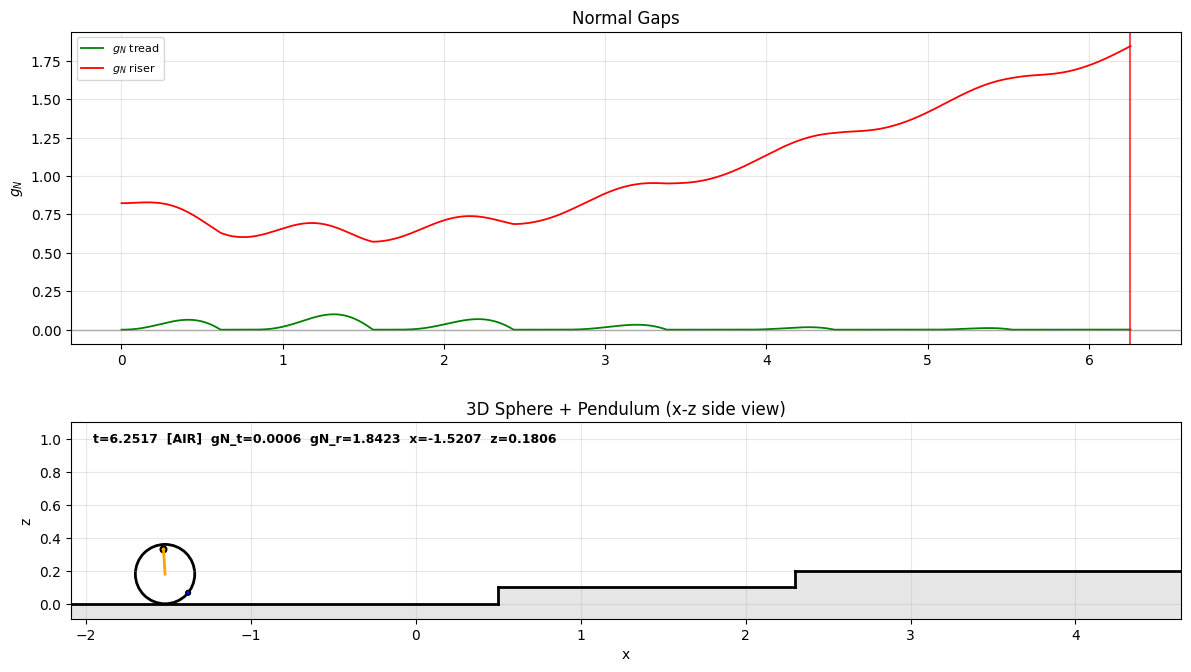

In [46]:
import matplotlib.animation as animation
from matplotlib.patches import Circle

# Animation parameters
step = max(1, ntime // 400)  # show ~400 frames
frames = range(0, ntime, step)

fig_anim = plt.figure(figsize=(12, 7))

# Top: normal gap time history
ax_top = fig_anim.add_subplot(2, 1, 1)
ax_top.plot(t, gN[0, :], 'g-', lw=1.3, label=r'$g_{N}$ tread')
if nN > 1:
    ax_top.plot(t, gN[1, :], 'r-', lw=1.3, label=r'$g_{N}$ riser')
ax_top.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax_top.set_ylabel(r'$g_N$')
ax_top.grid(True, alpha=0.3)
ax_top.set_title('Normal Gaps')
ax_top.legend(fontsize=8)
vline = ax_top.axvline(t[0], color='red', lw=1.5, alpha=0.7)

# Bottom: x-z side view animation
ax_bot = fig_anim.add_subplot(2, 1, 2)
ax_bot.set_aspect('equal')
ax_bot.set_xlabel('x')
ax_bot.set_ylabel('z')
ax_bot.set_title('3D Sphere + Pendulum (x-z side view)')
ax_bot.grid(True, alpha=0.3)

pad = 3 * R
x_lo = float(min(np.min(xG), np.min(xP))) - pad
x_hi = float(max(np.max(xG), np.max(xP))) + pad
z_lo = -0.5 * R
z_hi_val = float(max(np.max(zG), np.max(zP))) + pad
if n_stairs > 0:
    stair_x_end = stair_x_start + n_stairs * stair_width
    x_hi = max(x_hi, stair_x_end + pad)
    z_hi_val = max(z_hi_val, n_stairs * stair_height + 2 * R + pad)
ax_bot.set_xlim(x_lo, x_hi)
ax_bot.set_ylim(z_lo, z_hi_val)

# Draw stairs or ground
if n_stairs > 0:
    # Build filled stair polygon for shading
    fill_x = [x_lo]
    fill_z = [0.0]
    for seg in stair_segs:
        sx1, sz1, sx2, sz2 = seg
        # Clip to visible range
        if abs(sz2 - sz1) < 1e-12:  # horizontal
            sx1 = max(sx1, x_lo)
            sx2 = min(sx2, x_hi)
            if sx1 >= sx2:
                continue
        else:  # vertical
            if sx1 < x_lo or sx1 > x_hi:
                continue
        ax_bot.plot([sx1, sx2], [sz1, sz2], 'k-', lw=2)
        fill_x.extend([sx1, sx2])
        fill_z.extend([sz1, sz2])
    fill_x.append(x_hi)
    fill_z.append(fill_z[-1] if fill_z else 0.0)
    ax_bot.fill_between(fill_x, z_lo, fill_z, color='0.90', zorder=0)
else:
    ax_bot.axhline(0.0, color='k', lw=2)
    ax_bot.fill_between([x_lo, x_hi], -0.5*R, 0.0, color='0.90', zorder=0)

# Hoop circle
hoop = Circle((xG[0], zG[0]), R, fill=False, edgecolor='black', linewidth=2)
ax_bot.add_patch(hoop)

# Pendulum line and mass
pend_line, = ax_bot.plot([xG[0], xP[0]], [zG[0], zP[0]], 'orange', lw=2)
pend_dot = Circle((xP[0], zP[0]), 0.1*R, color='orange', ec='black', lw=1.5)
ax_bot.add_patch(pend_dot)

# Rim marker (tracking theta rotation in x-z)
rim_x0 = xG[0] + R * np.cos(theta[0])
rim_z0 = zG[0] - R * np.sin(theta[0])
rim_dot = Circle((rim_x0, rim_z0), 0.08*R, color='blue', ec='black', lw=1)
ax_bot.add_patch(rim_dot)

status_text = ax_bot.text(0.02, 0.95, '', transform=ax_bot.transAxes, va='top', fontsize=9, fontweight='bold')


def init():
    hoop.center = (xG[0], zG[0])
    pend_line.set_data([xG[0], xP[0]], [zG[0], zP[0]])
    pend_dot.center = (xP[0], zP[0])
    vline.set_xdata([t[0], t[0]])
    status_text.set_text('')
    return hoop, pend_line, pend_dot, rim_dot, vline, status_text


def animate(i):
    hoop.center = (xG[i], zG[i])
    pend_line.set_data([xG[i], xP[i]], [zG[i], zP[i]])
    pend_dot.center = (xP[i], zP[i])

    rx = xG[i] + R * np.cos(theta[i])
    rz = zG[i] - R * np.sin(theta[i])
    rim_dot.center = (rx, rz)

    vline.set_xdata([t[i], t[i]])

    gN_tread = gN[0, i]
    gN_riser = gN[1, i] if nN > 1 else 0.0
    # Contact status from index sets
    A_tread = contacts[0, i] if contacts.shape[0] > 0 else 0
    A_riser = contacts[5, i] if contacts.shape[0] > 5 else 0
    c_str = ''
    if A_tread: c_str += 'TREAD '
    if A_riser: c_str += 'RISER '
    if not c_str: c_str = 'AIR'
    status_text.set_text(
        f't={t[i]:.4f}  [{c_str.strip()}]  '
        f'gN_t={gN_tread:.4f}  gN_r={gN_riser:.4f}  x={xG[i]:.4f}  z={zG[i]:.4f}'
    )
    return hoop, pend_line, pend_dot, rim_dot, vline, status_text


anim = animation.FuncAnimation(fig_anim, animate, init_func=init,
                               frames=frames, interval=20, blit=True)

gif_path = OUTPUT_DIR / f"sphere3d_xz_{OUTPUT_DIR.name}.gif"
print("Saving GIF animation to:", gif_path)
anim.save(gif_path.as_posix(), writer=animation.PillowWriter(fps=30))
print("GIF saved to:", gif_path)

# Convert to MP4
try:
    import imageio
    mp4_path = OUTPUT_DIR / f"sphere3d_xz_{OUTPUT_DIR.name}.mp4"
    print("Converting GIF to MP4:", mp4_path)
    reader = imageio.get_reader(gif_path.as_posix())
    mp4_writer = imageio.get_writer(mp4_path.as_posix(), fps=30, codec='libx264', quality=8)
    for frame in reader:
        if frame.shape[-1] == 4:
            frame = frame[:, :, :3]
        mp4_writer.append_data(frame)
    reader.close()
    mp4_writer.close()
    print("MP4 saved to:", mp4_path)
except ImportError:
    print("imageio not available — skipping MP4 conversion")

plt.tight_layout()
plt.show()

## 3D Trajectory Plot

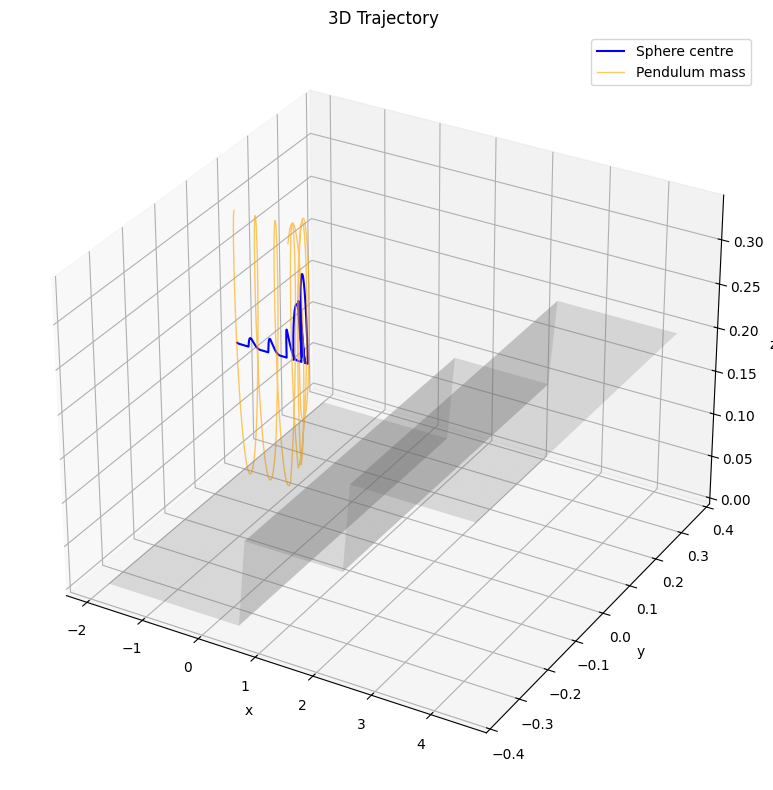

In [47]:
fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

ax_3d.plot(xG, yG, zG, 'b-', lw=1.5, label='Sphere centre')
ax_3d.plot(xP, yP, zP, 'orange', lw=1, alpha=0.6, label='Pendulum mass')

x_min = min(np.min(xG), np.min(xP)) - 2*R
x_max = max(np.max(xG), np.max(xP)) + 2*R
if n_stairs > 0:
    x_max = max(x_max, stair_x_start + n_stairs * stair_width + 2*R)

x_range = np.linspace(x_min, x_max, 50)
y_range = np.linspace(min(np.min(yG), np.min(yP)) - 2*R,
                      max(np.max(yG), np.max(yP)) + 2*R, 2)

if n_stairs > 0:
    Xg, Yg = np.meshgrid(x_range, y_range)
    Zg = np.zeros_like(Xg)
    for ix in range(Xg.shape[1]):
        xv = Xg[0, ix]
        zv = 0.0
        for si in range(n_stairs):
            x_left = stair_x_start + si * stair_width
            if xv >= x_left:
                zv = (si + 1) * stair_height
        Zg[:, ix] = zv
    ax_3d.plot_surface(Xg, Yg, Zg, alpha=0.2, color='gray')
else:
    Xg, Yg = np.meshgrid(x_range, y_range)
    ax_3d.plot_surface(Xg, Yg, np.zeros_like(Xg), alpha=0.15, color='gray')

ax_3d.set_xlabel('x')
ax_3d.set_ylabel('y')
ax_3d.set_zlabel('z')
ax_3d.set_title('3D Trajectory')
ax_3d.legend()

plt.tight_layout()
plt.show()

## Energy Analysis

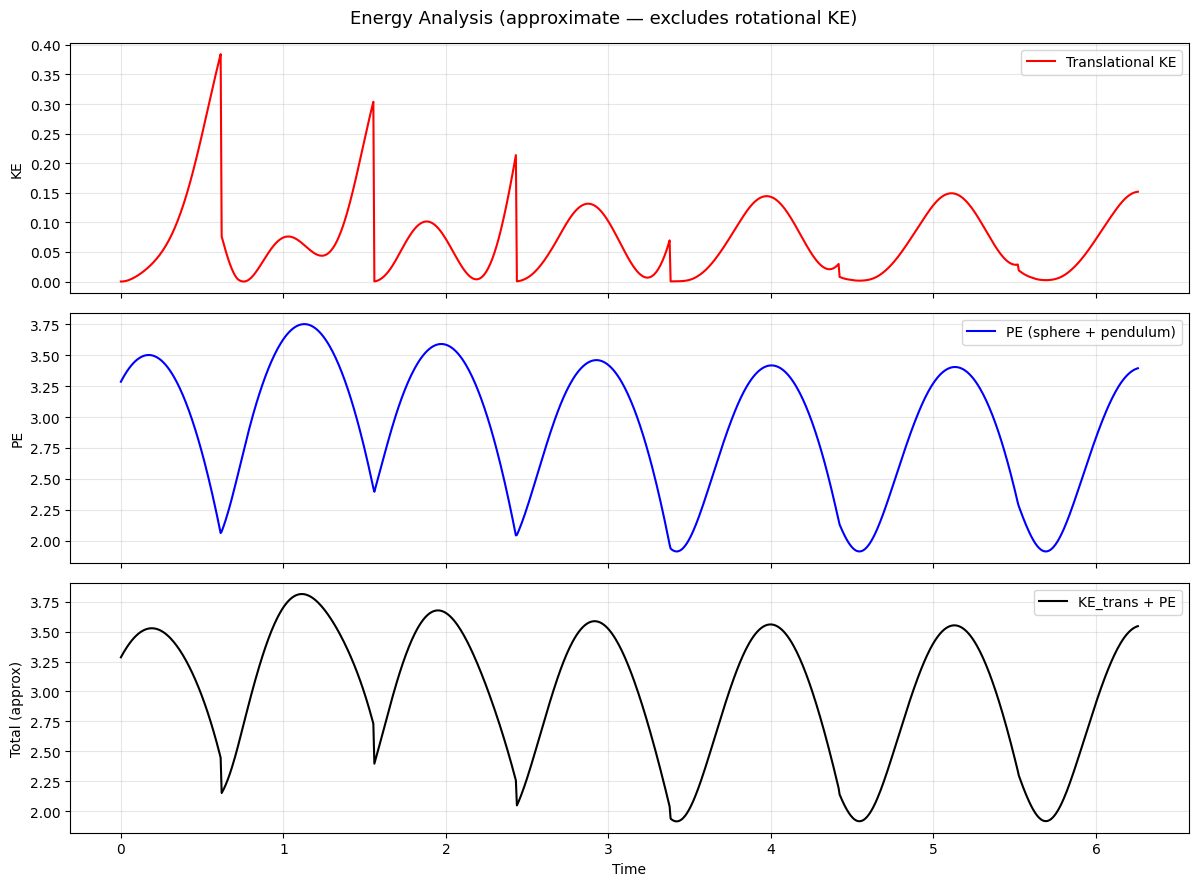

In [48]:
# Approximate energy analysis
# KE_trans = 0.5 * m_sphere * (xdot^2 + ydot^2 + zdot^2)
# PE = m_sphere * g * z + m_pend * g * z_pend
gr = 9.81  # nondim a_nd

KE_trans = 0.5 * m_sphere * (u[0,:]**2 + u[1,:]**2 + u[2,:]**2)
PE_sphere = m_sphere * gr * q[2, :]
PE_pend = m_pendulum_val * gr * zP
PE = PE_sphere + PE_pend

fig_en, (ax_ke, ax_pe, ax_tot) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig_en.suptitle('Energy Analysis (approximate — excludes rotational KE)', fontsize=13)

ax_ke.plot(t, KE_trans, 'r-', lw=1.5, label='Translational KE')
ax_ke.set_ylabel('KE')
ax_ke.legend()
ax_ke.grid(True, alpha=0.3)

ax_pe.plot(t, PE, 'b-', lw=1.5, label='PE (sphere + pendulum)')
ax_pe.set_ylabel('PE')
ax_pe.legend()
ax_pe.grid(True, alpha=0.3)

ax_tot.plot(t, KE_trans + PE, 'k-', lw=1.5, label='KE_trans + PE')
ax_tot.set_ylabel('Total (approx)')
ax_tot.set_xlabel('Time')
ax_tot.legend()
ax_tot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()